# **Model Training**

## Project
**Using Machine Learning to Predict Complaint Resolution Outcomes in Retail Banking: Evidence from Open Consumer Financial Complaint Data**

## Purpose of this notebook

This notebook builds machine learning models using the processed CFPB retail banking complaint dataset.

It continues from:

- `01_data_extraction.ipynb`
- `02_exploratory_analysis.ipynb`
- `03_hypothesis_tests.ipynb`

The main goal is to train, compare, evaluate, and save models that predict complaint resolution outcomes.

## Main modeling tasks

1. Build a **baseline model**.
2. Build a **structured-feature model** using complaint metadata.
3. Build a **structured + narrative model** using complaint text.
4. Handle class imbalance using class weights.
5. Evaluate models using accuracy, precision, recall, F1, ROC-AUC, and average precision.
6. Save model outputs, metrics, confusion matrices, and feature importance tables.

## Main target variable

The primary target is:

`timely_response_binary`

where:

- `1` = timely response
- `0` = not timely response

## Important leakage note

This notebook avoids using fields that may only be known after the company responds, such as:

- `company_response_to_consumer`
- `company_public_response`

Those fields are useful for analysis, but they should not be used as predictors when predicting timely response at or near complaint intake.

## Modeling Design

The notebook trains three main models:

| Model | Purpose |
|---|---|
| Dummy baseline | Shows the minimum benchmark |
| Structured logistic regression | Uses product, issue, channel, state, company group, and time features |
| Structured + TF-IDF logistic regression | Adds complaint narrative text features |
| Structured random forest | Provides a non-linear comparison on structured features |

The narrative model uses TF-IDF because it is simple, explainable, and appropriate for a first academic machine learning pipeline.

In [1]:
# -------------------------------------------------------------------
# Mount Google Drive
# -------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# -------------------------------------------------------------------
# Import libraries
# -------------------------------------------------------------------
from pathlib import Path
from datetime import datetime
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 180)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# -------------------------------------------------------------------
# Project folders and file paths
# -------------------------------------------------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/retail-complaint-resolution-ml")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_MODELS = PROJECT_ROOT / "outputs" / "models"

for folder in [DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = DATA_PROCESSED / "cfpb_retail_complaints_2017_2025.csv"

print("Project root:", PROJECT_ROOT)
print("Processed input file:", PROCESSED_FILE)
print("Model output folder:", OUTPUT_MODELS)
print("File exists:", PROCESSED_FILE.exists())

Project root: /content/drive/MyDrive/retail-complaint-resolution-ml
Processed input file: /content/drive/MyDrive/retail-complaint-resolution-ml/data/processed/cfpb_retail_complaints_2017_2025.csv
Model output folder: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/models
File exists: True


In [4]:
# -------------------------------------------------------------------
# Check processed dataset exists
# -------------------------------------------------------------------
if not PROCESSED_FILE.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Please run 01_data_extraction.ipynb first. "
        f"Expected file: {PROCESSED_FILE}"
    )

print("Processed dataset found.")
print(f"File size: {PROCESSED_FILE.stat().st_size / (1024**2):,.2f} MB")
print(f"Last modified: {datetime.fromtimestamp(PROCESSED_FILE.stat().st_mtime)}")

Processed dataset found.
File size: 1,241.13 MB
Last modified: 2026-07-15 21:18:36


## Step 1: Load the Processed Dataset

The processed file from Notebook 01 is loaded. The dataset is already filtered to the selected retail banking products and the 2017–2025 time period.

In [5]:
# -------------------------------------------------------------------
# Load processed dataset
# -------------------------------------------------------------------
df = pd.read_csv(PROCESSED_FILE, low_memory=False)

print("Dataset loaded.")
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", f"{df.shape[1]:,}")

df.head()

Dataset loaded.
Rows: 1,289,027
Columns: 25


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,date_received_raw,date_sent_to_company_raw,year_received,month_received,quarter_received,timely_response_binary,has_narrative,narrative_length,received_to_sent_lag_days
0,2025-07-05 08:45:32+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Changes in loan terms during the application p...,I signed an initial disclosure for a XXXX mort...,Company believes the complaint is the result o...,"Your Favorite Lenders, Inc",OH,441XX,NaN,Web,2026-05-05 13:43:00+00:00,Closed with explanation,Yes,21636268,2025-07-05T08:45:32.000Z,2026-05-05T13:43:00.000Z,2025,2025-07,2025Q3,1,1,516,304.0
1,2025-07-11 03:39:40+00:00,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am filing a complaint against Integra Credit...,NaN,"Deinde Online Services, LLC",FL,33068,NaN,Web,2026-04-21 17:42:21+00:00,Closed with explanation,Yes,21447929,2025-07-11T03:39:40.000Z,2026-04-21T17:42:21.000Z,2025,2025-07,2025Q3,1,1,998,284.0
2,2025-08-11 18:59:48+00:00,Mortgage,Conventional home mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"Del Toro Loan Servicing, Inc",CA,94552,Older American,Phone,2025-08-15 06:00:26+00:00,Closed with explanation,No,15198684,2025-08-11T18:59:48.000Z,2025-08-15T06:00:26.000Z,2025,2025-08,2025Q3,0,0,0,3.0
3,2025-08-17 01:15:29+00:00,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,"Dear all, My name is XXXX XXXX, my address is ...",Company disputes the facts presented in the co...,"RESCO, INC.",HI,96815,NaN,Web,2026-05-04 13:13:09+00:00,Closed with explanation,Yes,21848458,2025-08-17T01:15:29.000Z,2026-05-04T13:13:09.000Z,2025,2025-08,2025Q3,1,1,1805,260.0
4,2025-09-25 15:49:13+00:00,Mortgage,VA mortgage,Applying for a mortgage or refinancing an exis...,Loan estimate or other related disclosures,NaN,NaN,"Mortgage Express, Inc.",GA,30662,Servicemember,Web,2026-04-30 15:44:57+00:00,Closed with explanation,Yes,21669790,2025-09-25T15:49:13.000Z,2026-04-30T15:44:57.000Z,2025,2025-09,2025Q3,1,0,0,216.0


## Step 2: Basic Preparation

This step prepares the target variable and key modeling fields. It also recreates derived fields if they are missing.

In [6]:
# -------------------------------------------------------------------
# Basic preparation
# -------------------------------------------------------------------
# Convert dates
for col in ["date_received", "date_sent_to_company"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Create year/month/quarter if missing
if "year_received" not in df.columns and "date_received" in df.columns:
    df["year_received"] = df["date_received"].dt.year

if "month_received" not in df.columns and "date_received" in df.columns:
    df["month_received"] = df["date_received"].dt.to_period("M").astype(str)

if "quarter_received" not in df.columns and "date_received" in df.columns:
    df["quarter_received"] = df["date_received"].dt.to_period("Q").astype(str)

# Create binary target if missing
if "timely_response_binary" not in df.columns:
    df["timely_response_binary"] = (
        df["timely_response"]
        .astype(str)
        .str.lower()
        .str.strip()
        .map({"yes": 1, "no": 0})
    )

# Narrative features
if "has_narrative" not in df.columns:
    df["has_narrative"] = df["consumer_complaint_narrative"].notna().astype(int)

if "narrative_length" not in df.columns:
    df["narrative_length"] = df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

df["narrative_text"] = df["consumer_complaint_narrative"].fillna("").astype(str)

print("Preparation complete.")
print("Valid target records:", f"{df['timely_response_binary'].notna().sum():,}")

Preparation complete.
Valid target records: 1,289,027


In [7]:
# -------------------------------------------------------------------
# Helper functions
# -------------------------------------------------------------------
def save_table(table, filename):
    output_path = OUTPUT_TABLES / filename
    table.to_csv(output_path, index=False)
    print(f"Saved table: {output_path}")
    return output_path


def save_figure(filename):
    output_path = OUTPUT_FIGURES / filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


def evaluate_binary_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "average_precision": average_precision_score(y_test, y_score)
    }

    return metrics, y_pred, y_score


def save_confusion_matrix(y_true, y_pred, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
    save_table(cm_df.reset_index().rename(columns={"index": "actual"}), filename)
    return cm_df


def plot_confusion_matrix(cm_df, title, filename):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm_df.values, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(cm_df.columns))
    plt.xticks(tick_marks, cm_df.columns, rotation=45, ha="right")
    plt.yticks(tick_marks, cm_df.index)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            plt.text(j, i, cm_df.values[i, j], ha="center", va="center")

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    save_figure(filename)
    plt.show()


def plot_roc_curve(y_true, y_score, model_name, filename):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{model_name}, AUC={auc_value:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve: {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    save_figure(filename)
    plt.show()


def plot_precision_recall_curve(y_true, y_score, model_name, filename):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    ap_value = average_precision_score(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"{model_name}, AP={ap_value:.3f}")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    save_figure(filename)
    plt.show()


def plot_metric_comparison(metrics_df, filename):
    plot_df = metrics_df.set_index("model")
    metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

    plt.figure(figsize=(12, 6))
    plot_df[metric_cols].plot(kind="bar", figsize=(12, 6))
    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    save_figure(filename)
    plt.show()

## Step 3: Create Modeling Dataset

This notebook uses a controlled sample to keep training practical in Google Colab.

You may increase or reduce `MODEL_SAMPLE_SIZE` depending on runtime and memory.

In [8]:
# -------------------------------------------------------------------
# Modeling configuration
# -------------------------------------------------------------------
RANDOM_STATE = 42

# Increase this if Colab memory allows.
MODEL_SAMPLE_SIZE = 150_000

# Keep top categories to reduce extremely sparse one-hot encoding.
TOP_N_COMPANIES = 50
TOP_N_STATES = 50

print("Model sample size:", MODEL_SAMPLE_SIZE)
print("Random state:", RANDOM_STATE)

Model sample size: 150000
Random state: 42


In [9]:
# -------------------------------------------------------------------
# Build modeling dataset
# -------------------------------------------------------------------
model_df = df.dropna(subset=["timely_response_binary"]).copy()

# Group high-cardinality company and state fields
if "company" in model_df.columns:
    top_companies = model_df["company"].value_counts().head(TOP_N_COMPANIES).index
    model_df["company_grouped"] = np.where(model_df["company"].isin(top_companies), model_df["company"], "Other")
else:
    model_df["company_grouped"] = "Unknown"

if "state" in model_df.columns:
    top_states = model_df["state"].value_counts().head(TOP_N_STATES).index
    model_df["state_grouped"] = np.where(model_df["state"].isin(top_states), model_df["state"], "Other")
else:
    model_df["state_grouped"] = "Unknown"

# Define candidate features
categorical_features = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "submitted_via",
    "state_grouped",
    "company_grouped",
    "tags",
    "year_received"
]

numeric_features = [
    "has_narrative",
    "narrative_length"
]

text_feature = "narrative_text"

# Keep only available features
categorical_features = [col for col in categorical_features if col in model_df.columns]
numeric_features = [col for col in numeric_features if col in model_df.columns]

required_model_cols = ["timely_response_binary"] + categorical_features + numeric_features + [text_feature]
model_df = model_df[required_model_cols].copy()

# Fill missing values
for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

model_df[text_feature] = model_df[text_feature].fillna("").astype(str)
model_df["timely_response_binary"] = model_df["timely_response_binary"].astype(int)

# Stratified sample for runtime
if len(model_df) > MODEL_SAMPLE_SIZE:
    model_df, _ = train_test_split(
        model_df,
        train_size=MODEL_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=model_df["timely_response_binary"]
    )

print("Final modeling dataset shape:", model_df.shape)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Text feature:", text_feature)

target_distribution = model_df["timely_response_binary"].value_counts().reset_index()
target_distribution.columns = ["timely_response_binary", "count"]
target_distribution["percent"] = (target_distribution["count"] / target_distribution["count"].sum() * 100).round(2)

save_table(target_distribution, "model_training_target_distribution.csv")
target_distribution

Final modeling dataset shape: (150000, 13)
Categorical features: ['product', 'sub_product', 'issue', 'sub_issue', 'submitted_via', 'state_grouped', 'company_grouped', 'tags', 'year_received']
Numeric features: ['has_narrative', 'narrative_length']
Text feature: narrative_text
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_training_target_distribution.csv


,timely_response_binary,count,percent
0,1,147891,98.59
1,0,2109,1.41


## Step 4: Train-Test Split

A stratified split is used so the timely and not-timely response classes remain proportionally represented in both training and testing datasets.

In [10]:
# -------------------------------------------------------------------
# Train-test split
# -------------------------------------------------------------------
X = model_df[categorical_features + numeric_features + [text_feature]].copy()
y = model_df["timely_response_binary"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", f"{len(X_train):,}")
print("Testing rows:", f"{len(X_test):,}")
print("Training target distribution:")
display(y_train.value_counts(normalize=True).reset_index())
print("Testing target distribution:")
display(y_test.value_counts(normalize=True).reset_index())

Training rows: 105,000
Testing rows: 45,000
Training target distribution:


,timely_response_binary,proportion
0,1,0.985943
1,0,0.014057


Testing target distribution:


,timely_response_binary,proportion
0,1,0.985933
1,0,0.014067


# Model 1: Dummy Baseline

The baseline model predicts the most frequent class. This provides a minimum benchmark. Any useful model should improve on the baseline, especially on balanced accuracy, recall, F1, ROC-AUC, and average precision.

In [11]:
# -------------------------------------------------------------------
# Model 1: Dummy baseline
# -------------------------------------------------------------------
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

baseline_metrics, baseline_pred, baseline_score = evaluate_binary_classifier(
    baseline_model,
    X_test,
    y_test,
    model_name="Dummy baseline"
)

baseline_metrics

{'model': 'Dummy baseline',
 'accuracy': 0.9859333333333333,
 'balanced_accuracy': np.float64(0.5),
 'precision': 0.9859333333333333,
 'recall': 1.0,
 'f1': 0.9929168485011246,
 'roc_auc': np.float64(0.5),
 'average_precision': np.float64(0.9859333333333333)}

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_baseline_confusion_matrix.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_baseline_confusion_matrix.png


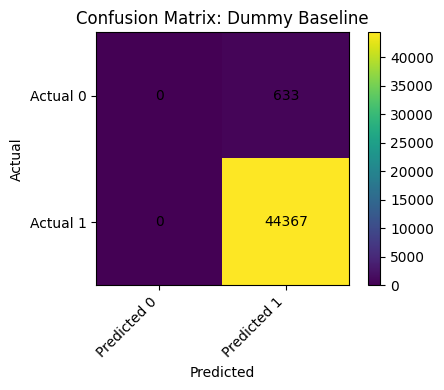

Saved baseline model.


In [12]:
# -------------------------------------------------------------------
# Save baseline model outputs
# -------------------------------------------------------------------
baseline_cm = save_confusion_matrix(
    y_test,
    baseline_pred,
    "model_baseline_confusion_matrix.csv"
)

plot_confusion_matrix(
    baseline_cm,
    title="Confusion Matrix: Dummy Baseline",
    filename="model_baseline_confusion_matrix.png"
)

joblib.dump(baseline_model, OUTPUT_MODELS / "model_baseline_dummy.pkl")
print("Saved baseline model.")

# Model 2: Structured Logistic Regression

This model uses only structured complaint fields, such as product, issue, state, company group, tags, submission channel, year, and simple numeric narrative indicators.

It does not use full complaint narrative text.

In [13]:
# -------------------------------------------------------------------
# Structured preprocessing
# -------------------------------------------------------------------
structured_features = categorical_features + numeric_features

structured_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), categorical_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

structured_logistic_model = Pipeline(steps=[
    ("preprocess", structured_preprocess),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

print("Structured logistic pipeline created.")

Structured logistic pipeline created.


In [14]:
# -------------------------------------------------------------------
# Train structured logistic regression
# -------------------------------------------------------------------
X_train_structured = X_train[structured_features].copy()
X_test_structured = X_test[structured_features].copy()

structured_logistic_model.fit(X_train_structured, y_train)

structured_logistic_metrics, structured_logistic_pred, structured_logistic_score = evaluate_binary_classifier(
    structured_logistic_model,
    X_test_structured,
    y_test,
    model_name="Structured logistic regression"
)

structured_logistic_metrics

{'model': 'Structured logistic regression',
 'accuracy': 0.7332666666666666,
 'balanced_accuracy': np.float64(0.7907616640479448),
 'precision': 0.9970817718252749,
 'recall': 0.7316023170374377,
 'f1': 0.8439567868332445,
 'roc_auc': np.float64(0.8505815399922042),
 'average_precision': np.float64(0.9973679536553437)}

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_logistic_confusion_matrix.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_logistic_confusion_matrix.png


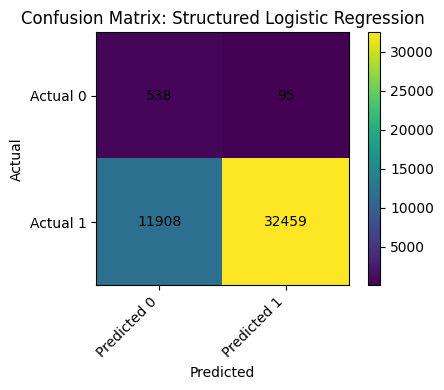

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_logistic_roc_curve.png


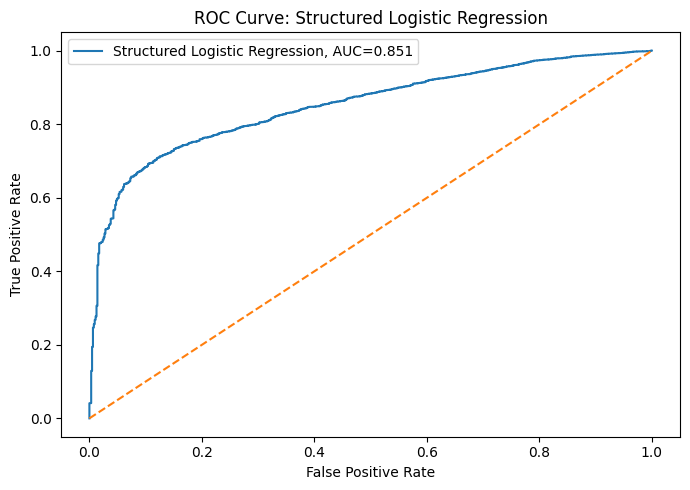

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_logistic_precision_recall_curve.png


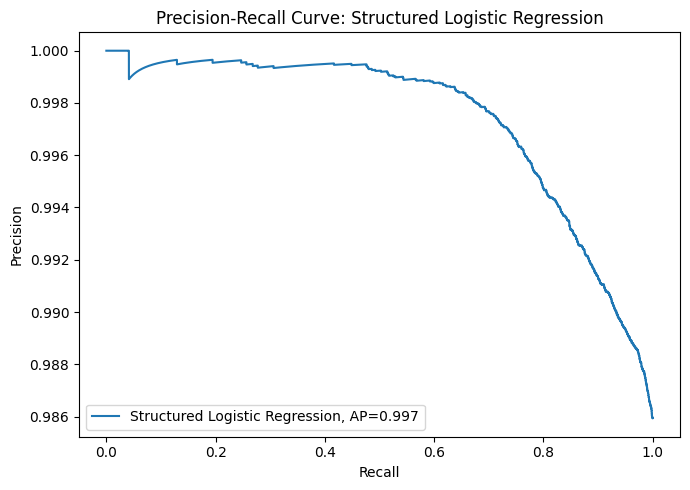

Saved structured logistic model.


In [15]:
# -------------------------------------------------------------------
# Save structured logistic outputs
# -------------------------------------------------------------------
structured_logistic_cm = save_confusion_matrix(
    y_test,
    structured_logistic_pred,
    "model_structured_logistic_confusion_matrix.csv"
)

plot_confusion_matrix(
    structured_logistic_cm,
    title="Confusion Matrix: Structured Logistic Regression",
    filename="model_structured_logistic_confusion_matrix.png"
)

plot_roc_curve(
    y_test,
    structured_logistic_score,
    "Structured Logistic Regression",
    "model_structured_logistic_roc_curve.png"
)

plot_precision_recall_curve(
    y_test,
    structured_logistic_score,
    "Structured Logistic Regression",
    "model_structured_logistic_precision_recall_curve.png"
)

joblib.dump(structured_logistic_model, OUTPUT_MODELS / "model_structured_logistic.pkl")
print("Saved structured logistic model.")

# Model 3: Structured + Narrative TF-IDF Logistic Regression

This model adds the consumer complaint narrative using TF-IDF text features.

TF-IDF converts text into weighted word/phrase features. This is useful for testing whether complaint narratives add predictive value beyond structured fields.

In [16]:
# -------------------------------------------------------------------
# Structured + narrative preprocessing
# -------------------------------------------------------------------
TEXT_MAX_FEATURES = 5000

structured_text_preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), categorical_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("text", TfidfVectorizer(
            max_features=TEXT_MAX_FEATURES,
            min_df=5,
            max_df=0.95,
            ngram_range=(1, 2),
            stop_words="english"
        ), text_feature)
    ],
    remainder="drop"
)

structured_text_logistic_model = Pipeline(steps=[
    ("preprocess", structured_text_preprocess),
    ("model", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

print("Structured + narrative logistic pipeline created.")

Structured + narrative logistic pipeline created.


In [17]:
# -------------------------------------------------------------------
# Train structured + narrative logistic regression
# -------------------------------------------------------------------
X_train_text = X_train[categorical_features + numeric_features + [text_feature]].copy()
X_test_text = X_test[categorical_features + numeric_features + [text_feature]].copy()

structured_text_logistic_model.fit(X_train_text, y_train)

structured_text_metrics, structured_text_pred, structured_text_score = evaluate_binary_classifier(
    structured_text_logistic_model,
    X_test_text,
    y_test,
    model_name="Structured + TF-IDF logistic regression"
)

structured_text_metrics

{'model': 'Structured + TF-IDF logistic regression',
 'accuracy': 0.8112,
 'balanced_accuracy': np.float64(0.7384071483897183),
 'precision': 0.9941317464253244,
 'recall': 0.8133071877746975,
 'f1': 0.8946742041059209,
 'roc_auc': np.float64(0.8356934410817485),
 'average_precision': np.float64(0.9970458277330394)}

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_text_logistic_confusion_matrix.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_text_logistic_confusion_matrix.png


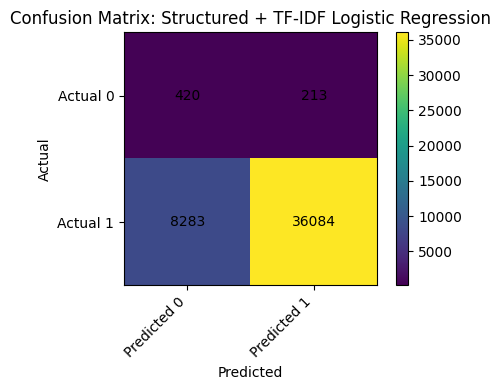

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_text_logistic_roc_curve.png


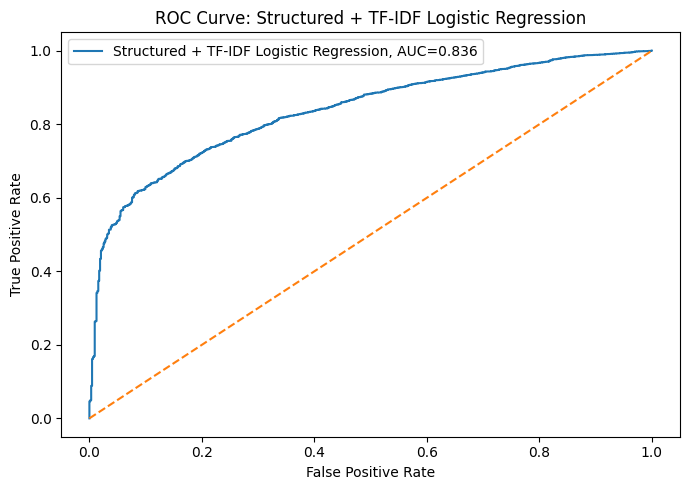

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_text_logistic_precision_recall_curve.png


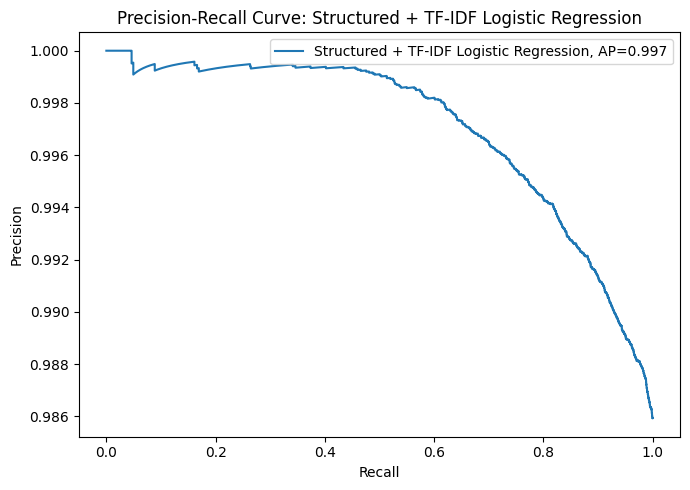

Saved structured + narrative logistic model.


In [18]:
# -------------------------------------------------------------------
# Save structured + narrative outputs
# -------------------------------------------------------------------
structured_text_cm = save_confusion_matrix(
    y_test,
    structured_text_pred,
    "model_structured_text_logistic_confusion_matrix.csv"
)

plot_confusion_matrix(
    structured_text_cm,
    title="Confusion Matrix: Structured + TF-IDF Logistic Regression",
    filename="model_structured_text_logistic_confusion_matrix.png"
)

plot_roc_curve(
    y_test,
    structured_text_score,
    "Structured + TF-IDF Logistic Regression",
    "model_structured_text_logistic_roc_curve.png"
)

plot_precision_recall_curve(
    y_test,
    structured_text_score,
    "Structured + TF-IDF Logistic Regression",
    "model_structured_text_logistic_precision_recall_curve.png"
)

joblib.dump(structured_text_logistic_model, OUTPUT_MODELS / "model_structured_text_logistic.pkl")
print("Saved structured + narrative logistic model.")

# Model 4: Structured Random Forest

This model uses structured fields only. Random forest can capture non-linear relationships and interactions, but it can be slower than logistic regression on large one-hot encoded datasets.

To keep runtime reasonable, it does not include full TF-IDF text features.

In [19]:
# -------------------------------------------------------------------
# Structured random forest model
# -------------------------------------------------------------------
structured_rf_model = Pipeline(steps=[
    ("preprocess", structured_preprocess),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

print("Structured random forest pipeline created.")

Structured random forest pipeline created.


In [20]:
# -------------------------------------------------------------------
# Train structured random forest
# -------------------------------------------------------------------
structured_rf_model.fit(X_train_structured, y_train)

structured_rf_metrics, structured_rf_pred, structured_rf_score = evaluate_binary_classifier(
    structured_rf_model,
    X_test_structured,
    y_test,
    model_name="Structured random forest"
)

structured_rf_metrics

{'model': 'Structured random forest',
 'accuracy': 0.7884,
 'balanced_accuracy': np.float64(0.8000347596207719),
 'precision': 0.9966080437818887,
 'recall': 0.7880632001262199,
 'f1': 0.8801510383889238,
 'roc_auc': np.float64(0.8747802465226937),
 'average_precision': np.float64(0.9978286290057902)}

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_random_forest_confusion_matrix.csv
Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_random_forest_confusion_matrix.png


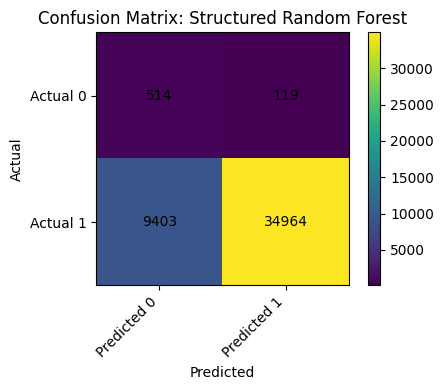

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_random_forest_roc_curve.png


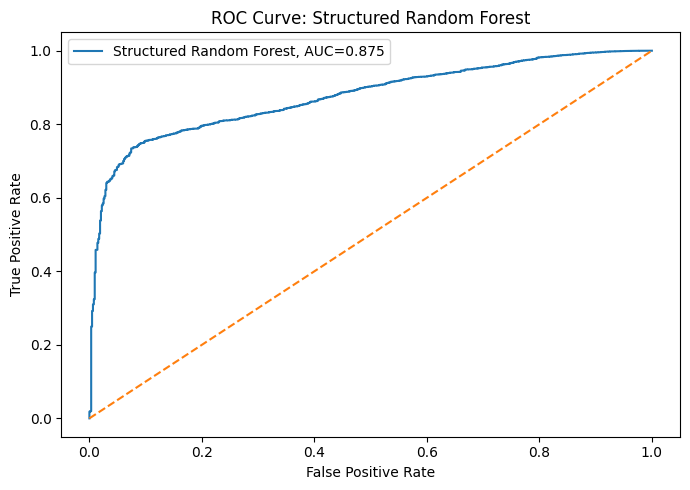

Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_random_forest_precision_recall_curve.png


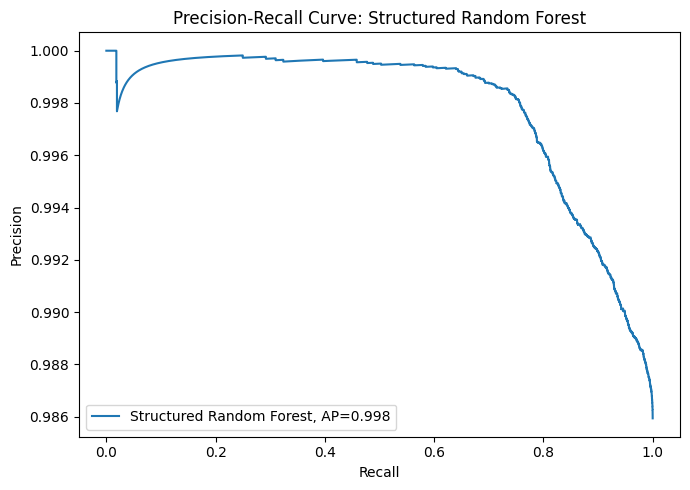

Saved structured random forest model.


In [21]:
# -------------------------------------------------------------------
# Save structured random forest outputs
# -------------------------------------------------------------------
structured_rf_cm = save_confusion_matrix(
    y_test,
    structured_rf_pred,
    "model_structured_random_forest_confusion_matrix.csv"
)

plot_confusion_matrix(
    structured_rf_cm,
    title="Confusion Matrix: Structured Random Forest",
    filename="model_structured_random_forest_confusion_matrix.png"
)

plot_roc_curve(
    y_test,
    structured_rf_score,
    "Structured Random Forest",
    "model_structured_random_forest_roc_curve.png"
)

plot_precision_recall_curve(
    y_test,
    structured_rf_score,
    "Structured Random Forest",
    "model_structured_random_forest_precision_recall_curve.png"
)

joblib.dump(structured_rf_model, OUTPUT_MODELS / "model_structured_random_forest.pkl")
print("Saved structured random forest model.")

# Model Performance Comparison

This section compares all trained models in one table.

In [22]:
# -------------------------------------------------------------------
# Model comparison table
# -------------------------------------------------------------------
model_metrics = pd.DataFrame([
    baseline_metrics,
    structured_logistic_metrics,
    structured_text_metrics,
    structured_rf_metrics
])

metric_cols = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

for col in metric_cols:
    model_metrics[col] = model_metrics[col].round(4)

save_table(model_metrics, "model_training_performance_comparison.csv")

model_metrics

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_training_performance_comparison.csv


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Dummy baseline,0.9859,0.5000,0.9859,1.0000,0.9929,0.5000,0.9859
1,Structured logistic regression,0.7333,0.7908,0.9971,0.7316,0.8440,0.8506,0.9974
2,Structured + TF-IDF logistic regression,0.8112,0.7384,0.9941,0.8133,0.8947,0.8357,0.9970
3,Structured random forest,0.7884,0.8000,0.9966,0.7881,0.8802,0.8748,0.9978


Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_training_performance_comparison.png


<Figure size 1200x600 with 0 Axes>

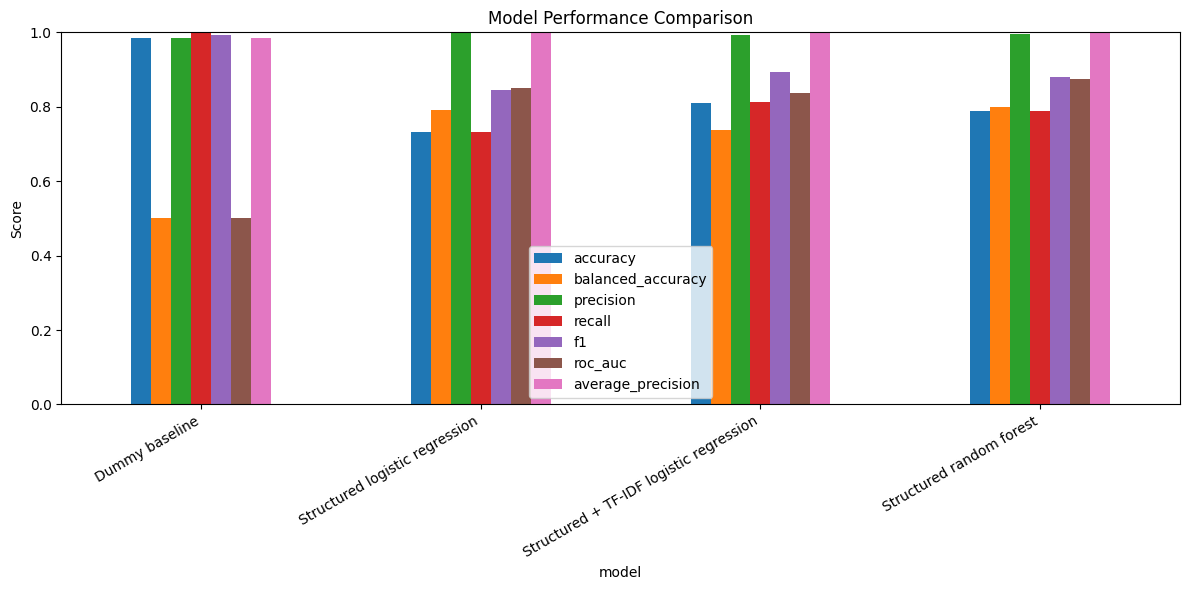

In [23]:
# -------------------------------------------------------------------
# Visual model comparison
# -------------------------------------------------------------------
plot_metric_comparison(
    model_metrics,
    filename="model_training_performance_comparison.png"
)

In [24]:
# -------------------------------------------------------------------
# Select best model by ROC-AUC
# -------------------------------------------------------------------
best_model_row = model_metrics.sort_values("roc_auc", ascending=False).iloc[0]
best_model_name = best_model_row["model"]

print("Best model by ROC-AUC:", best_model_name)
display(best_model_row.to_frame().T)

best_model_summary = pd.DataFrame([{
    "selection_metric": "roc_auc",
    "best_model": best_model_name,
    "roc_auc": best_model_row["roc_auc"],
    "f1": best_model_row["f1"],
    "recall": best_model_row["recall"],
    "precision": best_model_row["precision"],
    "average_precision": best_model_row["average_precision"]
}])

save_table(best_model_summary, "model_training_best_model_summary.csv")

best_model_summary

Best model by ROC-AUC: Structured random forest


,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
3,Structured random forest,0.7884,0.8,0.9966,0.7881,0.8802,0.8748,0.9978


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_training_best_model_summary.csv


,selection_metric,best_model,roc_auc,f1,recall,precision,average_precision
0,roc_auc,Structured random forest,0.8748,0.8802,0.7881,0.9966,0.9978


## Feature Importance: Logistic Regression Coefficients

For logistic regression models, positive coefficients increase the probability of timely response, while negative coefficients decrease it.

This section saves the strongest positive and negative coefficients for the structured logistic model and the structured + narrative model.

In [25]:
# -------------------------------------------------------------------
# Feature names helper
# -------------------------------------------------------------------
def get_pipeline_feature_names(pipeline):
    preprocess = pipeline.named_steps["preprocess"]
    try:
        return preprocess.get_feature_names_out()
    except Exception as e:
        print("Could not get feature names directly:", e)
        return None


def save_logistic_coefficients(pipeline, filename, top_n=50):
    feature_names = get_pipeline_feature_names(pipeline)
    if feature_names is None:
        return None

    coefficients = pipeline.named_steps["model"].coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "absolute_coefficient": np.abs(coefficients)
    }).sort_values("absolute_coefficient", ascending=False)

    save_table(coef_df, filename)

    print("Top positive coefficients")
    display(coef_df.sort_values("coefficient", ascending=False).head(top_n))

    print("Top negative coefficients")
    display(coef_df.sort_values("coefficient", ascending=True).head(top_n))

    return coef_df

In [26]:
# -------------------------------------------------------------------
# Structured logistic coefficients
# -------------------------------------------------------------------
structured_coef_df = save_logistic_coefficients(
    structured_logistic_model,
    "model_structured_logistic_coefficients.csv",
    top_n=30
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_logistic_coefficients.csv
Top positive coefficients


,feature,coefficient,absolute_coefficient
237,cat__sub_issue_You never received your bill or...,3.859460,3.859460
15,cat__sub_product_Conventional adjustable mortg...,3.123114,3.123114
32,cat__sub_product_Manufactured home loan,3.114827,3.114827
212,cat__sub_issue_Problem with paying off the loan,3.018931,3.018931
204,cat__sub_issue_Problem using the card to withd...,3.001193,3.001193
343,cat__company_grouped_U.S. BANCORP,2.882532,2.882532
287,cat__state_grouped_SD,2.859468,2.859468
145,cat__sub_issue_Changes in terms mid-deal or af...,2.858604,2.858604
26,cat__sub_product_Home equity loan or line of c...,2.771374,2.771374
66,cat__issue_Credit monitoring or identity theft...,2.685512,2.685512


Top negative coefficients


,feature,coefficient,absolute_coefficient
328,cat__company_grouped_Other,-4.591129,4.591129
298,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",-3.868397,3.868397
338,"cat__company_grouped_Shellpoint Partners, LLC",-3.724020,3.724020
326,cat__company_grouped_Netspend Corporation,-3.667572,3.667572
342,cat__company_grouped_TRUIST FINANCIAL CORPORATION,-3.414774,3.414774
301,"cat__company_grouped_Block, Inc.",-3.386160,3.386160
345,cat__company_grouped_WELLS FARGO & COMPANY,-3.370834,3.370834
322,"cat__company_grouped_LoanCare, LLC",-3.339669,3.339669
182,cat__sub_issue_Late or other fees,-2.587303,2.587303
171,"cat__sub_issue_Excess mileage, damage, or wear...",-2.577584,2.577584


In [27]:
# -------------------------------------------------------------------
# Structured + narrative logistic coefficients
# -------------------------------------------------------------------
structured_text_coef_df = save_logistic_coefficients(
    structured_text_logistic_model,
    "model_structured_text_logistic_coefficients.csv",
    top_n=30
)

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_text_logistic_coefficients.csv
Top positive coefficients


,feature,coefficient,absolute_coefficient
3775,text__provide,4.350903,4.350903
3703,text__principal,4.098066,4.098066
3586,text__person,3.784646,3.784646
237,cat__sub_issue_You never received your bill or...,3.734058,3.734058
1046,text__atm,3.675547,3.675547
4504,text__suntrust,3.317739,3.317739
2372,text__flagstar,3.232493,3.232493
4668,text__told xxxx,3.211729,3.211729
1950,text__didnt,3.185688,3.185688
1048,text__attached,3.181304,3.181304


Top negative coefficients


,feature,coefficient,absolute_coefficient
1542,text__codes,-4.832375,4.832375
1180,text__better,-4.716601,4.716601
328,cat__company_grouped_Other,-4.494481,4.494481
5347,text__years ago,-4.491853,4.491853
2394,text__forged,-4.369356,4.369356
1183,text__billing,-4.367036,4.367036
1973,text__disbursement,-4.326325,4.326325
1262,text__california,-4.109073,4.109073
1724,text__coverage,-4.098655,4.098655
5296,text__xxxx today,-3.956235,3.956235


## Feature Importance: Random Forest

Random forest feature importance shows which encoded structured features were most useful for the tree-based model.

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_structured_random_forest_feature_importance.csv


,feature,importance
328,cat__company_grouped_Other,0.277721
298,"cat__company_grouped_BANK OF AMERICA, NATIONAL...",0.044469
320,cat__company_grouped_JPMORGAN CHASE & CO.,0.040352
22,cat__sub_product_General-purpose credit card o...,0.029113
303,cat__company_grouped_CAPITAL ONE FINANCIAL COR...,0.026219
3,cat__product_Credit card,0.025999
345,cat__company_grouped_WELLS FARGO & COMPANY,0.023733
234,cat__sub_issue_Unknown,0.022910
305,"cat__company_grouped_CITIBANK, N.A.",0.020700
361,num__narrative_length,0.016963


Saved figure: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/figures/model_structured_random_forest_feature_importance.png


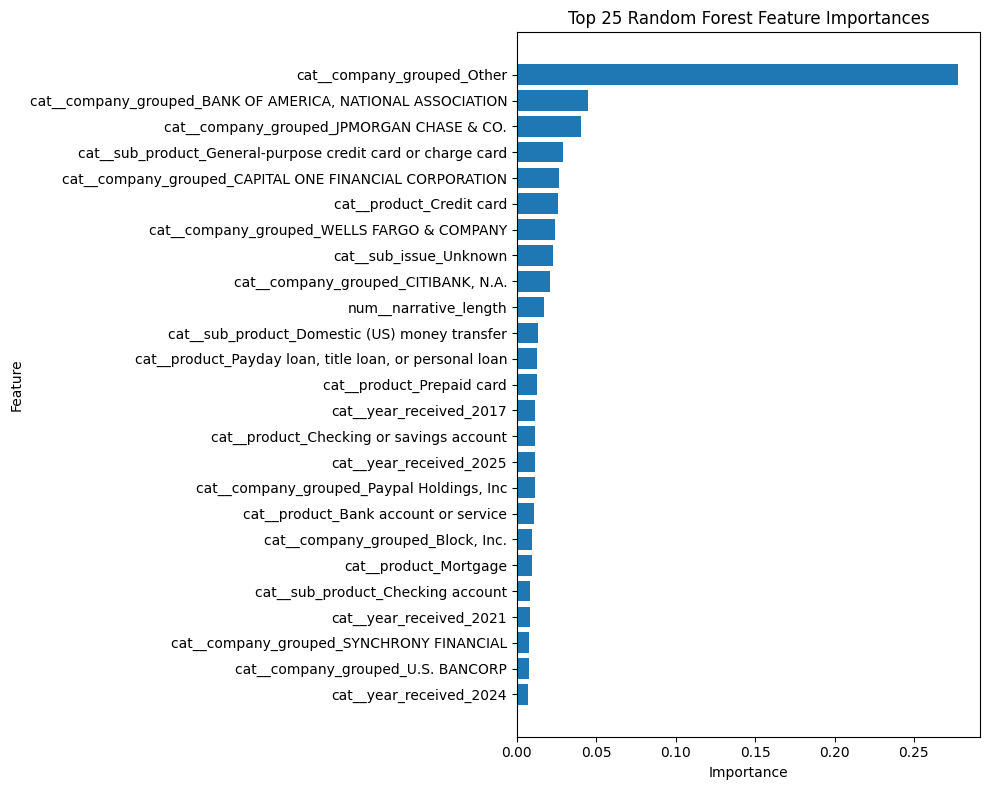

In [28]:
# -------------------------------------------------------------------
# Random forest feature importance
# -------------------------------------------------------------------
rf_feature_names = get_pipeline_feature_names(structured_rf_model)

if rf_feature_names is not None:
    rf_importance = structured_rf_model.named_steps["model"].feature_importances_

    rf_importance_df = pd.DataFrame({
        "feature": rf_feature_names,
        "importance": rf_importance
    }).sort_values("importance", ascending=False)

    save_table(rf_importance_df, "model_structured_random_forest_feature_importance.csv")

    display(rf_importance_df.head(50))

    top_rf = rf_importance_df.head(25).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_rf["feature"].astype(str), top_rf["importance"])
    plt.title("Top 25 Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    save_figure("model_structured_random_forest_feature_importance.png")
    plt.show()
else:
    print("Feature names were not available.")

# Optional: Company Response Outcome Model

The main target is timely response. This optional section creates a simplified company-response target and trains a multi-class logistic regression model.

This can support RQ2, but it should be treated as secondary because company response categories are often imbalanced.

In [29]:
# -------------------------------------------------------------------
# Optional multi-class target preparation
# -------------------------------------------------------------------
RUN_COMPANY_RESPONSE_MODEL = True

def simplify_company_response(value):
    text = str(value).lower()

    if "monetary relief" in text:
        return "Relief provided"
    elif "non-monetary relief" in text:
        return "Relief provided"
    elif "explanation" in text:
        return "Closed with explanation"
    elif "in progress" in text:
        return "In progress"
    elif text in ["nan", "none", ""]:
        return np.nan
    else:
        return "Other response"

if RUN_COMPANY_RESPONSE_MODEL and "company_response_to_consumer" in df.columns:
    response_df = df.copy()
    response_df["company_response_group"] = response_df["company_response_to_consumer"].apply(simplify_company_response)
    response_df = response_df.dropna(subset=["company_response_group"]).copy()

    print("Company response target distribution:")
    response_target_counts = response_df["company_response_group"].value_counts().reset_index()
    response_target_counts.columns = ["company_response_group", "count"]
    response_target_counts["percent"] = (response_target_counts["count"] / response_target_counts["count"].sum() * 100).round(2)

    save_table(response_target_counts, "model_company_response_group_distribution.csv")
    display(response_target_counts)
else:
    print("Company response model skipped.")

Company response target distribution:
Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_company_response_group_distribution.csv


,company_response_group,count,percent
0,Closed with explanation,1038396,80.56
1,Relief provided,247704,19.22
2,Other response,2844,0.22
3,In progress,22,0.00


In [30]:
# -------------------------------------------------------------------
# Optional multi-class company response model
# -------------------------------------------------------------------
if RUN_COMPANY_RESPONSE_MODEL and "company_response_to_consumer" in df.columns:
    response_model_df = response_df.copy()

    # Recreate grouped fields
    top_companies_response = response_model_df["company"].value_counts().head(TOP_N_COMPANIES).index
    top_states_response = response_model_df["state"].value_counts().head(TOP_N_STATES).index

    response_model_df["company_grouped"] = np.where(
        response_model_df["company"].isin(top_companies_response),
        response_model_df["company"],
        "Other"
    )

    response_model_df["state_grouped"] = np.where(
        response_model_df["state"].isin(top_states_response),
        response_model_df["state"],
        "Other"
    )

    if "has_narrative" not in response_model_df.columns:
        response_model_df["has_narrative"] = response_model_df["consumer_complaint_narrative"].notna().astype(int)

    if "narrative_length" not in response_model_df.columns:
        response_model_df["narrative_length"] = response_model_df["consumer_complaint_narrative"].fillna("").astype(str).str.len()

    response_features = categorical_features + numeric_features
    response_features = [col for col in response_features if col in response_model_df.columns]

    response_model_df = response_model_df[response_features + ["company_response_group"]].copy()

    for col in response_features:
        if col in numeric_features:
            response_model_df[col] = pd.to_numeric(response_model_df[col], errors="coerce").fillna(0)
        else:
            response_model_df[col] = response_model_df[col].fillna("Unknown").astype(str)

    if len(response_model_df) > MODEL_SAMPLE_SIZE:
        response_model_df, _ = train_test_split(
            response_model_df,
            train_size=MODEL_SAMPLE_SIZE,
            random_state=RANDOM_STATE,
            stratify=response_model_df["company_response_group"]
        )

    X_resp = response_model_df[response_features]
    y_resp = response_model_df["company_response_group"]

    X_train_resp, X_test_resp, y_train_resp, y_test_resp = train_test_split(
        X_resp,
        y_resp,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y_resp
    )

    response_categorical = [col for col in response_features if col not in numeric_features]
    response_numeric = [col for col in response_features if col in numeric_features]

    response_preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), response_categorical),
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), response_numeric)
        ],
        remainder="drop"
    )

    response_model = Pipeline(steps=[
        ("preprocess", response_preprocess),
        ("model", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])

    response_model.fit(X_train_resp, y_train_resp)

    y_resp_pred = response_model.predict(X_test_resp)

    response_report = classification_report(
        y_test_resp,
        y_resp_pred,
        output_dict=True,
        zero_division=0
    )

    response_report_df = pd.DataFrame(response_report).T.reset_index().rename(columns={"index": "class"})

    save_table(response_report_df, "model_company_response_classification_report.csv")

    display(response_report_df)

    response_cm = confusion_matrix(y_test_resp, y_resp_pred, labels=response_model.named_steps["model"].classes_)

    response_cm_df = pd.DataFrame(
        response_cm,
        index=[f"Actual {label}" for label in response_model.named_steps["model"].classes_],
        columns=[f"Predicted {label}" for label in response_model.named_steps["model"].classes_]
    )

    save_table(response_cm_df.reset_index().rename(columns={"index": "actual"}), "model_company_response_confusion_matrix.csv")

    joblib.dump(response_model, OUTPUT_MODELS / "model_company_response_logistic.pkl")
    print("Saved company response model.")
else:
    print("Company response model skipped.")

Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_company_response_classification_report.csv


,class,precision,recall,f1-score,support
0,Closed with explanation,0.919391,0.551528,0.689460,36252.0000
1,In progress,0.000000,0.000000,0.000000,1.0000
2,Other response,0.015077,0.777778,0.029581,99.0000
3,Relief provided,0.362824,0.760638,0.491299,8648.0000
4,accuracy,0.592200,0.592200,0.592200,0.5922
5,macro avg,0.324323,0.522486,0.302585,45000.0000
6,weighted avg,0.810421,0.592200,0.649911,45000.0000


Saved table: /content/drive/MyDrive/retail-complaint-resolution-ml/outputs/tables/model_company_response_confusion_matrix.csv
Saved company response model.


# Final Output Checklist

This cell confirms that the main model files, metric tables, and charts were created.

In [31]:
# -------------------------------------------------------------------
# Final output checklist
# -------------------------------------------------------------------
expected_outputs = [
    OUTPUT_TABLES / "model_training_target_distribution.csv",
    OUTPUT_TABLES / "model_training_performance_comparison.csv",
    OUTPUT_TABLES / "model_training_best_model_summary.csv",
    OUTPUT_TABLES / "model_structured_logistic_coefficients.csv",
    OUTPUT_TABLES / "model_structured_text_logistic_coefficients.csv",
    OUTPUT_TABLES / "model_structured_random_forest_feature_importance.csv",
    OUTPUT_FIGURES / "model_training_performance_comparison.png",
    OUTPUT_MODELS / "model_baseline_dummy.pkl",
    OUTPUT_MODELS / "model_structured_logistic.pkl",
    OUTPUT_MODELS / "model_structured_text_logistic.pkl",
    OUTPUT_MODELS / "model_structured_random_forest.pkl"
]

checklist = pd.DataFrame([
    {
        "file": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / (1024**2), 4) if path.exists() else None
    }
    for path in expected_outputs
])

checklist

,file,exists,size_mb
0,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
1,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0004
2,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0001
3,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0287
4,/content/drive/MyDrive/retail-complaint-resolu...,True,0.2901
5,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0226
6,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0867
7,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0010
8,/content/drive/MyDrive/retail-complaint-resolu...,True,0.0268
9,/content/drive/MyDrive/retail-complaint-resolu...,True,0.2664


## Model Training Summary Notes

Use these points in the report after running the notebook:

1. The dummy baseline shows the minimum benchmark.
2. The structured logistic regression model provides an interpretable baseline using complaint metadata.
3. The structured + TF-IDF model tests whether narrative text improves prediction.
4. The random forest model provides a non-linear comparison using structured fields.
5. If the timely-response target is highly imbalanced, accuracy should not be used alone.
6. Recall, F1, ROC-AUC, and average precision should receive more attention.
7. Feature importance should be interpreted as association, not causation.
8. CFPB complaints are observational public complaint data and do not represent total bank customer populations.

## Next Step

Continue with:

`05_model_interpretation.ipynb`

That notebook should focus on:

- deeper feature interpretation;
- model explainability;
- error analysis;
- fairness and geographic review;
- business recommendations;
- final tables for the capstone report.